<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Life Expectancy - Regression</center></h1>


# Data Description

The target dataset was retrieved from Kaggle at https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who.

## Content

The Global Health Observatory (GHO) data repository under World Health Organization (WHO) keeps track of the health status as well as many other related factors for all countries.

The data-set related to life expectancy, health factors for 193 countries has been collected from the same WHO data repository website and its corresponding economic data was collected from United Nation website. Among all categories of health-related factors only those critical factors were chosen which are more representative. All predicting variables were divided into several broad categories: Immunization related factors, Mortality factors, Economical factors and Social factors.

## Objective

This project aims at replying to the following questions:
1. Is it possible to build a regressor to predict life expectancy?
2. What are the predicting variables actually affecting life expectancy?

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
sns.set()

# Data Import and Overview

In [42]:
data = pd.read_csv('data/Life Expectancy Data.csv')

data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# EDA
Dataset statistics.

In [43]:
data.shape

(2938, 22)

In [44]:
data.info();

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [45]:
data.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [46]:
for column_name in data.columns:
    data.rename(columns={column_name: column_name.strip()}, inplace=True)

list(data.columns)

['Country',
 'Year',
 'Status',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

### Peculiar features

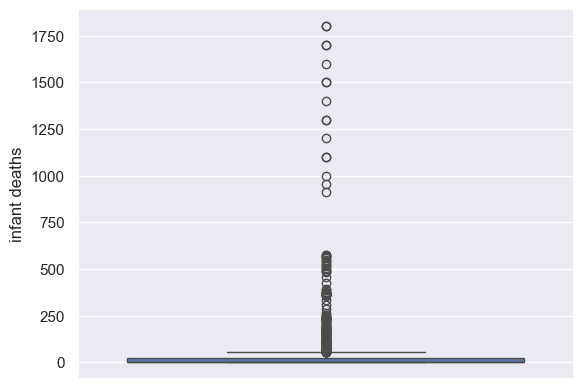

In [47]:
sns.boxplot(data['infant deaths']);

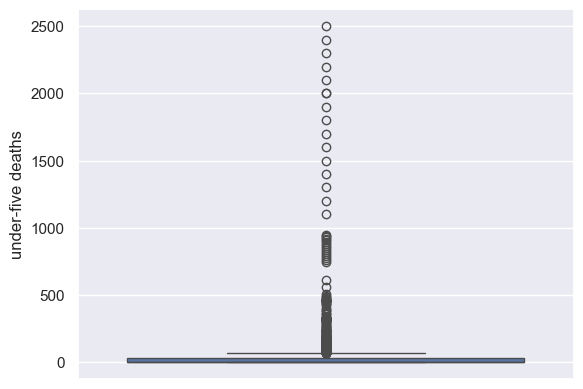

In [48]:
sns.boxplot(data['under-five deaths']);

These features expectedly (and fortunately) show low average and standard deviation, with a consistent amount of outliers.

## Testing assumptions for linear regression

## Target normality
Let's analyze the distribution and skewness of the target variable.

Life expectancy distribution skewness: -0.6386047358773552


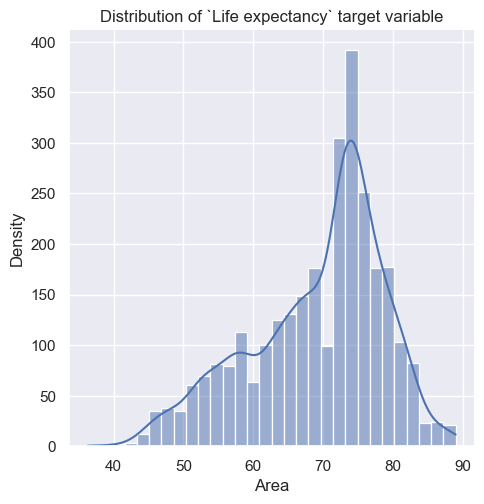

In [49]:
dist = sns.displot(data['Life expectancy'], kde=True)
dist.set(xlabel='Area', ylabel='Density', title='Distribution of `Life expectancy` target variable')

print('Life expectancy distribution skewness: {}'.format(data['Life expectancy'].skew()))

The target variable is fairly normally distributed (rule of thumb - abs(skewness) < 0.75). It's already adequate for linear regression.

### Linearity


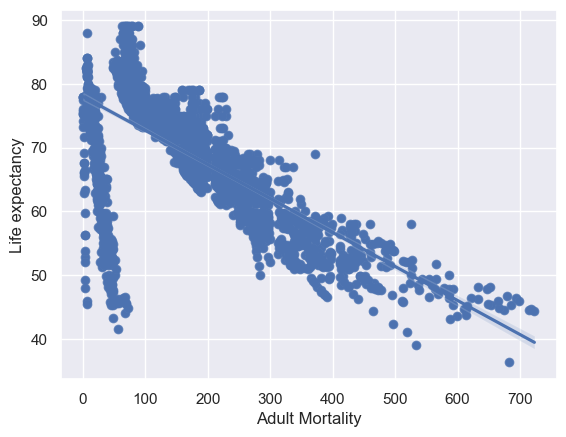

In [50]:
sns.scatterplot(x=data['Adult Mortality'], y=data['Life expectancy'])
sns.regplot(x=data['Adult Mortality'], y=data['Life expectancy']);

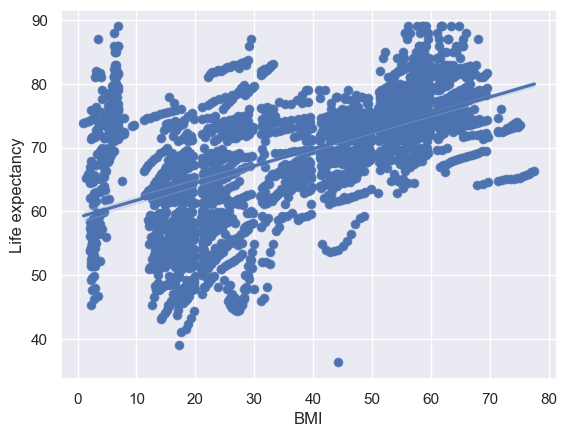

In [51]:
sns.scatterplot(x=data['BMI'], y=data['Life expectancy'])
sns.regplot(x=data['BMI'], y=data['Life expectancy']);

Analyzed predictors show fair linearity patterns with respect to target variable.

### Homoscedasticity

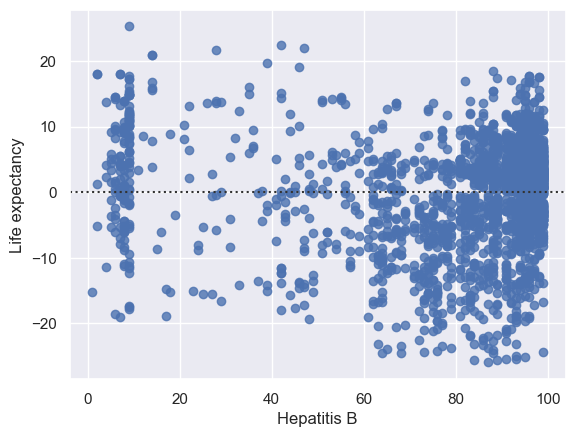

In [53]:
sns.residplot(x=data['Hepatitis B'], y=data['Life expectancy']);

The analyzed variable shows constant variance across residuals over predictor values - homoscedasticity bound is met for `Hepatitis B` feature.

### Multicollinearity

,Pearson Correlation Value,Correlating Feature
thinness 1-19 years,0.939102,thinness 5-9 years
thinness 5-9 years,0.939102,thinness 1-19 years
percentage expenditure,0.899373,GDP
GDP,0.899373,percentage expenditure
Income composition of resources,0.800092,Schooling
Schooling,0.800092,Income composition of resources
Life expectancy,0.751975,Schooling
Adult Mortality,0.696359,Life expectancy
Polio,0.673553,Diphtheria
Diphtheria,0.673553,Polio


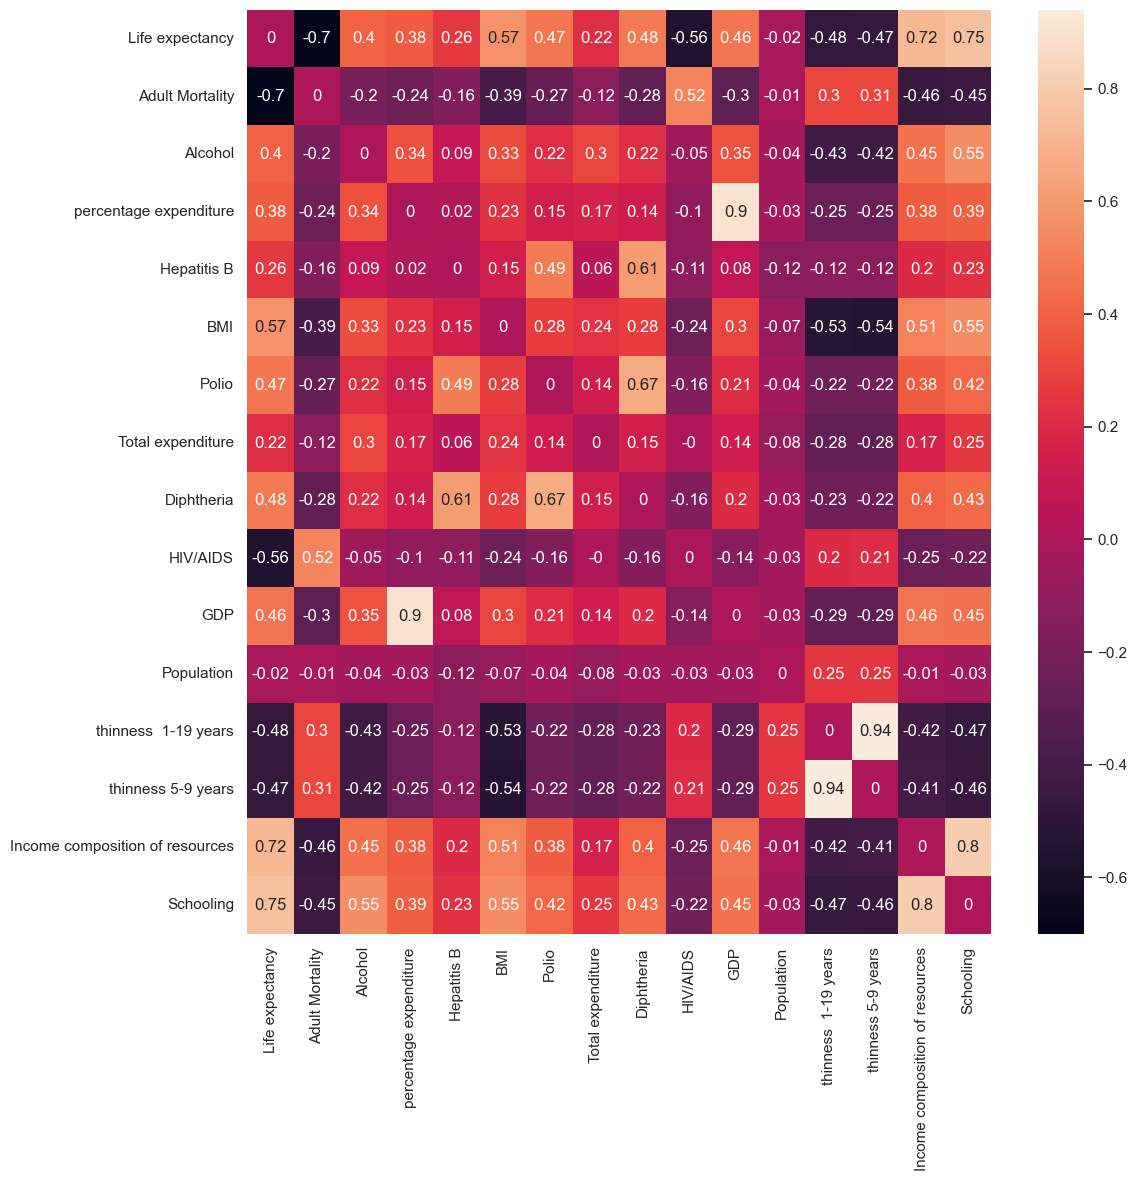

In [54]:
fig, ax = plt.subplots(figsize=(12, 12))
float_data = data.select_dtypes('float')
corr_mat = float_data.corr()

for col in float_data.columns:
    corr_mat.loc[col, col] = 0.0

sns.heatmap(round(corr_mat, 2), annot=True)

maximal_correlations = pd.concat([corr_mat.abs().max(), corr_mat.abs().idxmax()], axis=1).rename(columns={0: 'Pearson Correlation Value', 1: 'Correlating Feature'}).sort_values(by='Pearson Correlation Value', ascending=False)
display(maximal_correlations)

We can notice strong multicollinearity in the feature pairs (`percentage expenditure`, `GDP`), (`Hepatitis B`, `Diphteria`), (`Polio`, `Diphteria`), (`thinness 1-19 years`, `thinness 5-9 years`), (`Income composition of resources`, `Schooling`). This could cause problems at regression time but can be addressed with a proper regularization strategy.

## Missing values analysis & resolution

Given that we have 10/2938 missing values for the target variable we're going to drop them, as we want to prevent their incorrect imputation (and thus incorrect performance evaluation).

In [55]:
data.dropna(subset=['Life expectancy'], inplace=True)
data.reset_index(drop=True, inplace=True)

data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [56]:
column_nans = data.isnull().sum().to_frame('null values').sort_values(by=['null values'], ascending=False)

columns_with_nans = column_nans[column_nans['null values'] > 0]
columns_with_nans

,null values
Population,644
Hepatitis B,553
GDP,443
Total expenditure,226
Alcohol,193
Income composition of resources,160
Schooling,160
thinness 1-19 years,32
thinness 5-9 years,32
BMI,32


In [57]:
for column in columns_with_nans.index:
    feature_nans_by_country = data[column].isnull().groupby(data['Country']).sum().to_frame()
    display(feature_nans_by_country[feature_nans_by_country[column] > 0])

,Population
Country,
Antigua and Barbuda,16
Bahamas,16
Bahrain,16
Barbados,16
Bolivia (Plurinational State of),16
Brunei Darussalam,16
Congo,16
Cuba,16
Czechia,16


,Hepatitis B
Country,
Algeria,4
Angola,7
Antigua and Barbuda,1
Argentina,2
Australia,1
...,...
United Kingdom of Great Britain and Northern Ireland,16
United Republic of Tanzania,2
Uzbekistan,2


,GDP
Country,
Bahamas,16
Bolivia (Plurinational State of),16
Congo,16
Czechia,16
Côte d'Ivoire,16
Democratic People's Republic of Korea,16
Democratic Republic of the Congo,16
Egypt,16
Eritrea,4


,Total expenditure
Country,
Algeria,1
Angola,1
Antigua and Barbuda,1
Argentina,1
Armenia,1
...,...
Venezuela (Bolivarian Republic of),1
Viet Nam,1
Yemen,1


,Alcohol
Country,
Algeria,1
Angola,1
Antigua and Barbuda,1
Argentina,1
Armenia,1
...,...
Venezuela (Bolivarian Republic of),1
Viet Nam,1
Yemen,1


...

,thinness 1-19 years
Country,
South Sudan,16
Sudan,16


,thinness 5-9 years
Country,
South Sudan,16
Sudan,16


,BMI
Country,
South Sudan,16
Sudan,16


,Diphtheria
Country,
Montenegro,6
South Sudan,11
Timor-Leste,2


,Polio
Country,
Montenegro,6
South Sudan,11
Timor-Leste,2


Some features show missing values over the entire data of some countries, whereas some others are missing for some specific years only. Missing data mainly characterizes countries in which data collection was not possible.

All columns with missing values are characterized by non-negative float values. Strategy for missing data imputation:
1) For each feature: group data by `Country` and fill in missing values with the mean of that feature in the country.
2) Cases in which a feature is null over all the rows of the related country were not addressed in step 1. For each feature still characterized by missing values: fill in missing values with the mean of that feature in the whole dataset.

In [58]:
for column in columns_with_nans.index:
    data[column] = data.groupby('Country')[column].apply(lambda x: x.fillna(x.mean())).reset_index()[column]

In [59]:
data.isnull().sum().to_frame('Null Values')

,Null Values
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,16
percentage expenditure,0
Hepatitis B,144
Measles,0


In [60]:
for column in columns_with_nans.index:
    data[column] = data[column].fillna(data[column].mean())

data.isnull().sum().to_frame('Null Values')

,Null Values
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


## Encodings

Encoding `Year` ordinally.

In [61]:
data['Year'] = data['Year'] - 2000

data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,15,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,14,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,13,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,12,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,11,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,4,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,3,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,1,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


One-hot encoding categorical variables `Country` and `Status`.

In [62]:
data['Status'].value_counts().to_frame()

,count
Status,
Developing,2416
Developed,512


In [63]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_hot = ColumnTransformer(transformers=[
	('one_hot', OneHotEncoder(sparse_output=False, drop='first'), ['Country', 'Status'])    # drop first to prevent multicollinearity
], remainder='passthrough')
X = one_hot.fit_transform(data)
data = pd.DataFrame(data=X, columns=one_hot.get_feature_names_out())

for col in data.columns:
    data.rename({col: col.split('__')[1]}, axis=1, inplace=True)

data

,Country_Albania,Country_Algeria,Country_Angola,Country_Antigua and Barbuda,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# Modeling

In [64]:
y_col = 'Life expectancy'
y = data[y_col]
X = data.drop(y_col, axis=1)

In [65]:
from sklearn.linear_model import (
    ElasticNet,
    LassoCV,
    LinearRegression,
    RidgeCV,
)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

### Data split into train and test datasets

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

### Model #1 - Vanilla linear regression

In [67]:
def rmse(y_test, y_pred):
    return round(float(mean_squared_error(y_test, y_pred)), 3)

In [68]:
lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred = lm.predict(X_test)

rmse(y_test, y_pred)

4.226

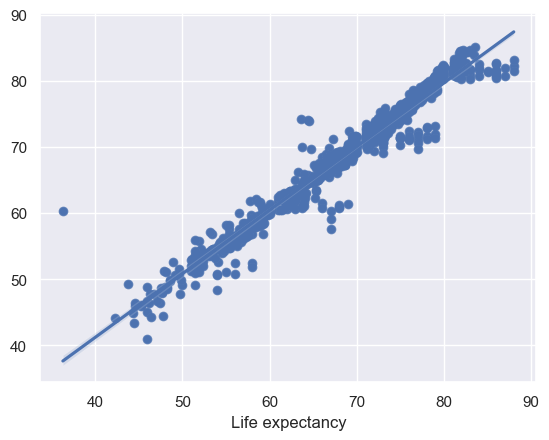

In [69]:
sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred);

Simple linear regression already provides significant results.

### Model #2 - MinMaxScaler + Vanilla linear regression

In [70]:
pipe_2 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lm', LinearRegression()),
])
pipe_2.fit(X_train, y_train)
y_pred = pipe_2.predict(X_test)

rmse(y_test, y_pred)

4.226

Scaling doesn't have any impact on simple linear regression.

### Model #3 - MinMaxScaler + Ridge regression with 5-fold cross validation

In [71]:
pipe_3 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lm', RidgeCV(cv=5, alphas=np.geomspace(0.000001, 1000, 10))),
])
pipe_3.fit(X_train, y_train)
y_pred = pipe_3.predict(X_test)

rmse(y_test, y_pred)

4.226

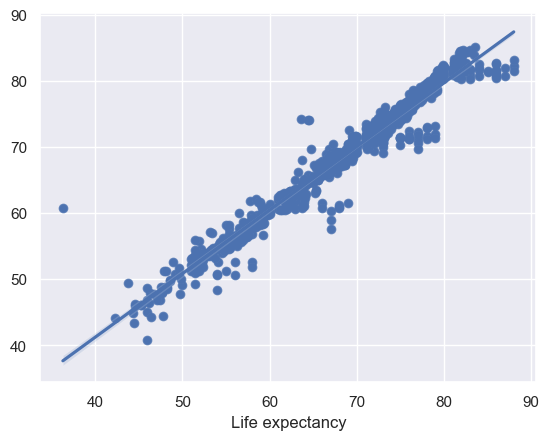

In [72]:
sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred);

Ridge regularization doesn't provide any improvement to final results.

### Model #4 - MinMaxScaler + Lasso regression with 5-fold cross validation

In [73]:
pipe_4 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lm', LassoCV(cv=5, max_iter=1000000, alphas=np.geomspace(0.000001, 1, 10))),
])
pipe_4.fit(X_train, y_train)
y_pred = pipe_4.predict(X_test)

rmse(y_test, y_pred)

4.222

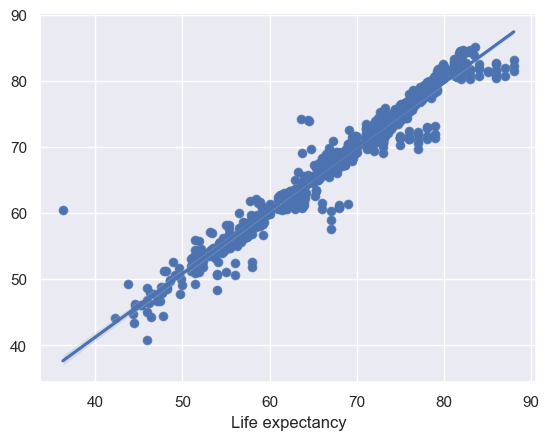

In [74]:
sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred);

Lasso regularization yielded slightly better results than other tested methods.

### Model #5 - MinMaxScaler + ElasticNet regression with 5-fold cross validation

In [75]:
pipe_5 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lm', ElasticNet(max_iter=1000000)),
])
params = {
    'lm__l1_ratio': np.linspace(0.1, 0.9, 8),
    'lm__alpha': np.geomspace(0.000001, 1000, 10),
}
grid = GridSearchCV(pipe_5, params, cv=5)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)

rmse(y_test, y_pred)

4.227

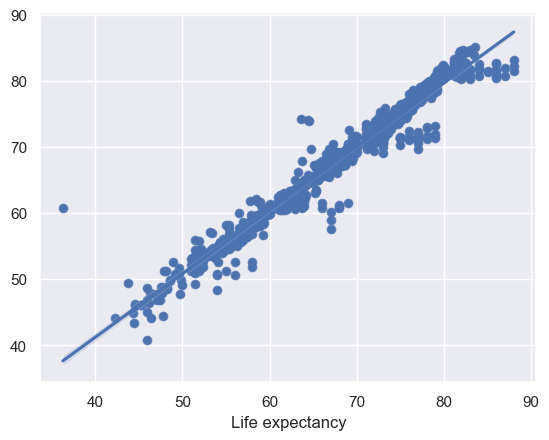

In [76]:
sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred);

ElasticNet, combining the effects of Ridge and Lasso at varying amounts, showed to be inadequate to the problem at hand, as it yielded the worst result among tested models.

## Model Selection

Model #4 with Lasso cross-validated regression resulted as the best-performing model, with `RMSE=4.222`, a result slightly better than the baseline (model #1).

## Model/Predictors Interpretability

Let's extract regression coefficients for non-country predictors from the winning model (#4) and observe how each variable impacts the output.

In [77]:
coef = pd.DataFrame(index=X.columns, data={'coefficient': pipe_4.steps[1][1].__dict__['coef_']})

coef[-20:]

,coefficient
Status_Developing,-21.616221
Year,4.159147
Adult Mortality,-0.711132
infant deaths,137.863110
Alcohol,-1.072253
percentage expenditure,2.843380
Hepatitis B,-0.017147
Measles,-1.845796
BMI,-0.165240
under-five deaths,-139.477036


These coefficients are averaged over all countries, so their interpretability should be considered as a vague average global indicator, with the country contribution acting as additional bias. For instance, we can observe how the `HIV/AIDS` predictor provides a strong negative contribution to the target variable `Life expectancy`, or notice the positive contribution of `Schooling`, independently of the country.

# Conclusion and Next Steps

The target life expectancy dataset was cleaned and preprocessed so as to be fed as input to a series of Regression models, and the Lasso cross-validated regressor resulted as the best-performing one for the task at hand.

Regression coefficients extracted from the model allow to identify how much each predictor affects life expectancy.

Future investigations could involve a similar study but focused on each country, assuming it's possible to acquire enough country-specific data.

Copyright @ IBM Corporation. All rights reserved.
